**step 1 : Import libraries**

In [18]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2: Load Dataset**

In [19]:
# Step 2: Load Dataset
df = pd.read_csv('/Messy_Employee_dataset.csv')

 **Step 3: Initial Inspection**

In [20]:
# Step 3: Initial Inspection
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

  Employee_ID First_Name Last_Name   Age   Department_Region    Status  \
0     EMP1000        Bob     Davis  25.0   DevOps-California    Active   
1     EMP1001        Bob     Brown   NaN       Finance-Texas    Active   
2     EMP1002      Alice     Jones   NaN        Admin-Nevada   Pending   
3     EMP1003        Eva     Davis  25.0        Admin-Nevada  Inactive   
4     EMP1004      Frank  Williams  25.0  Cloud Tech-Florida    Active   

    Join_Date     Salary                       Email       Phone  \
0    4/2/2021   59767.65       bob.davis@example.com -1651623197   
1   7/10/2020   65304.66       bob.brown@example.com -1898471390   
2   12/7/2023   88145.90     alice.jones@example.com -5596363211   
3  11/27/2021   69450.99       eva.davis@example.com -3476490784   
4    1/5/2022  109324.61  frank.williams@example.com -1586734256   

  Performance_Score  Remote_Work  
0           Average         True  
1         Excellent         True  
2              Good         True  
3     

**Step 4: Data Cleaning**

In [21]:
# Step 4: Data Cleaning
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Salary'].replace('N/A', np.nan, inplace=True)
df['Salary'] = pd.to_numeric(df['Salary'])
df.drop_duplicates(inplace=True)

/tmp/ipykernel_691/224544421.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_691/224544421.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

**Step 5: Feature Engineering**

In [22]:
# Step 5: Feature Engineering
df['Region'] = df['Department_Region'].str.split('-').str[-1]
df['Department'] = df['Department_Region'].str.split('-').str[0]
df['Join_Date'] = pd.to_datetime(df['Join_Date'], errors='coerce')
df['Join_Year'] = df['Join_Date'].dt.year

**Step 6: Exploratory Data Analysis (EDA)**

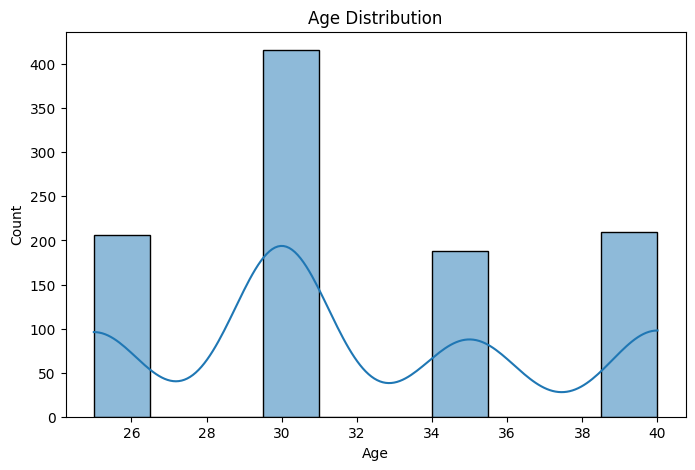

In [23]:
# Step 6: Exploratory Data Analysis (EDA)
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title("Age Distribution")
plt.show()

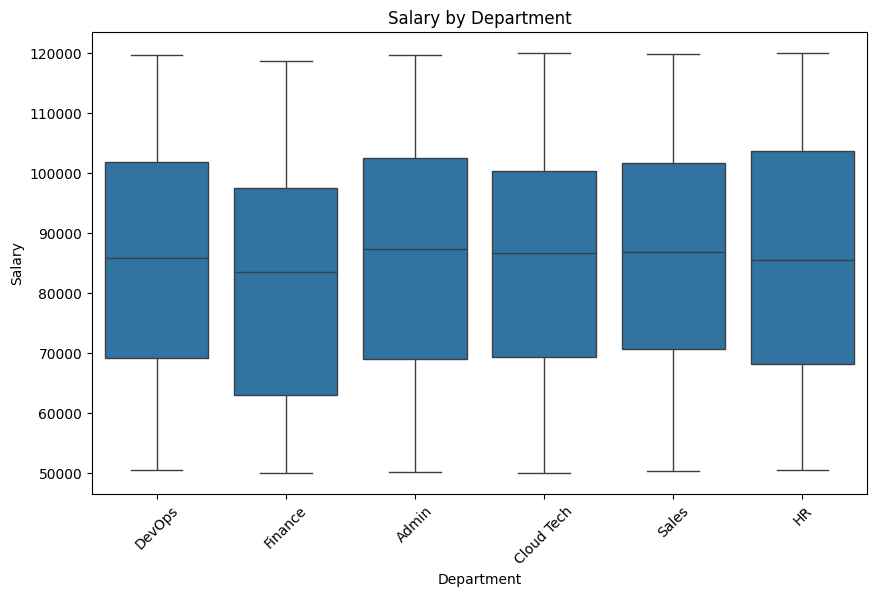

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Department', y='Salary', data=df)
plt.xticks(rotation=45)
plt.title("Salary by Department")
plt.show()

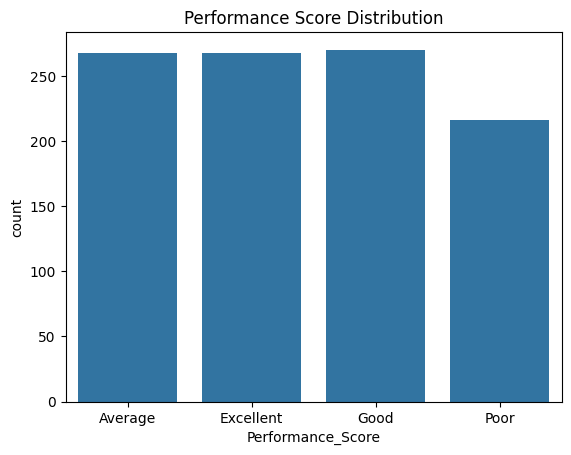

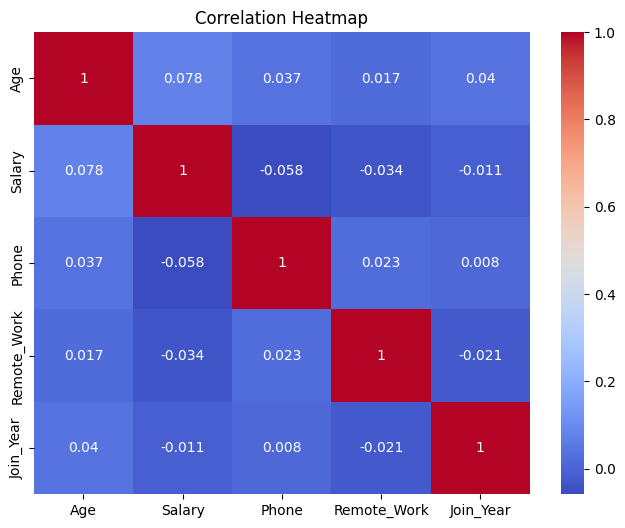

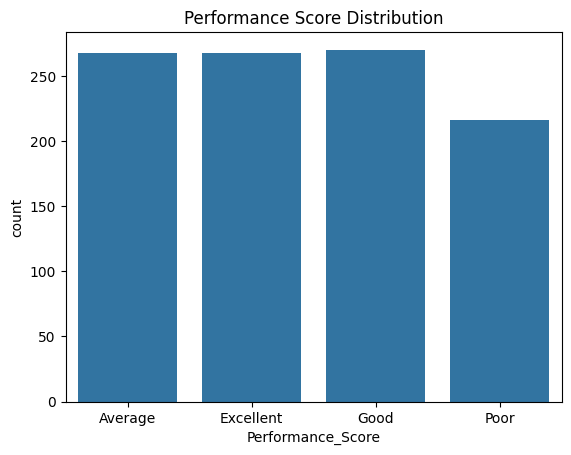

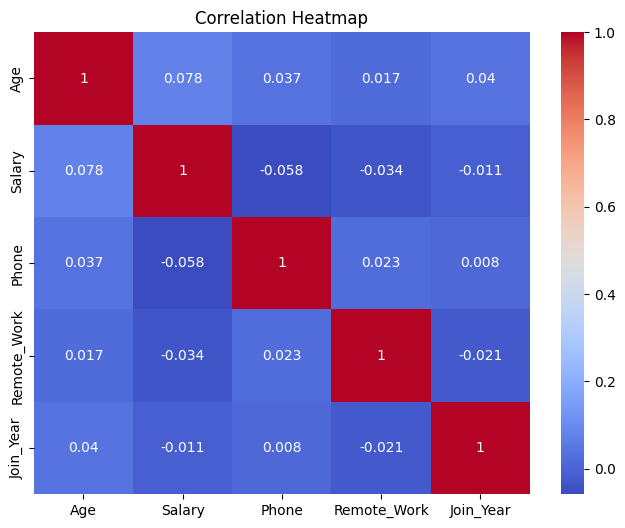

In [25]:
sns.countplot(x='Performance_Score', data=df)
plt.title("Performance Score Distribution")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
sns.countplot(x='Performance_Score', data=df)
plt.title("Performance Score Distribution")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Step 7: Business Questions**

In [26]:
# Step 7: Business Questions

# 1. Which department has the highest average salary?
print("Average Salary by Department:")
print(df.groupby('Department')['Salary'].mean().sort_values(ascending=False))

Average Salary by Department:
Department
Sales         86896.681029
DevOps        86016.023641
HR            85473.643174
Admin         85191.922795
Cloud Tech    84923.036241
Finance       82240.610417
Name: Salary, dtype: float64


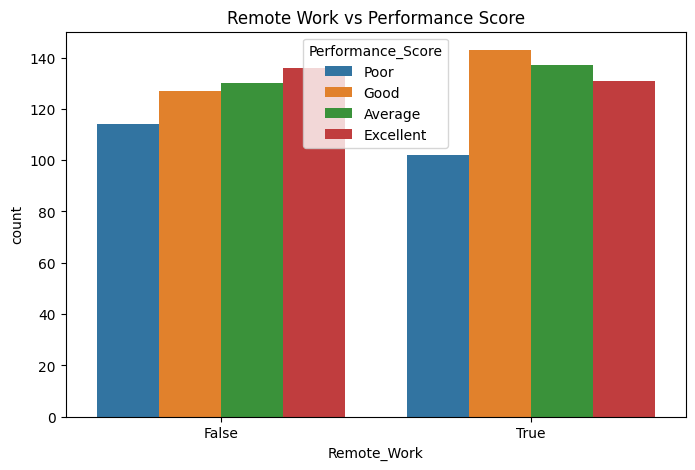

In [27]:
# 2. Is remote work associated with higher performance scores?
plt.figure(figsize=(8,5))
sns.countplot(x='Remote_Work', hue='Performance_Score', data=df)
plt.title("Remote Work vs Performance Score")
plt.show()

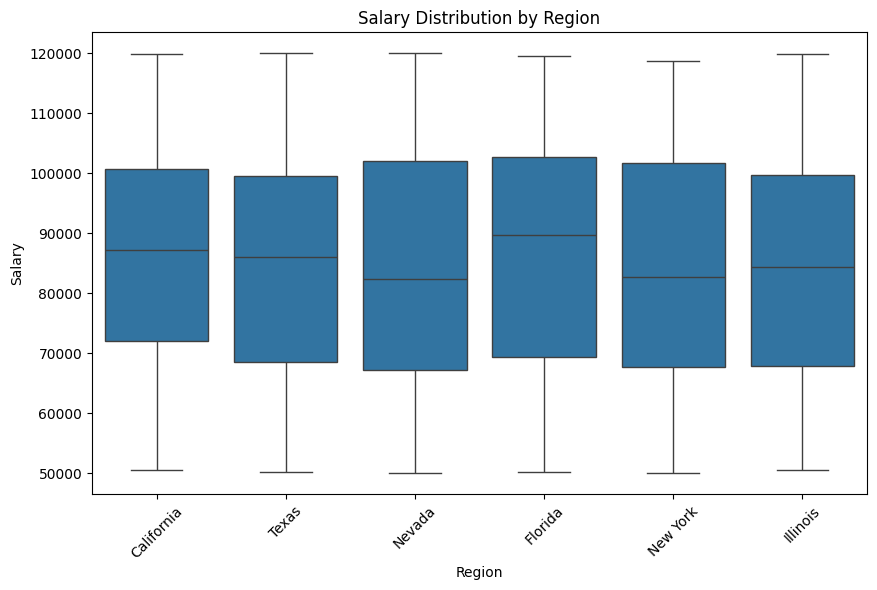

In [28]:
# 3. What is the salary distribution across different regions?
plt.figure(figsize=(10,6))
sns.boxplot(x='Region', y='Salary', data=df)
plt.xticks(rotation=45)
plt.title("Salary Distribution by Region")
plt.show()

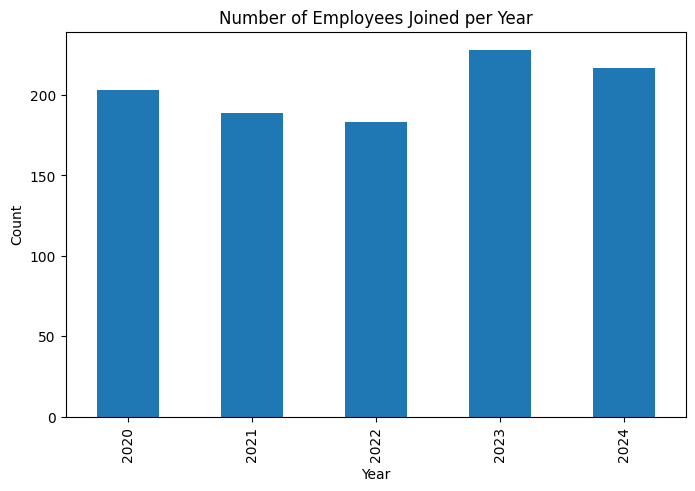

In [29]:
# 4. Which year had the most employee joinings?
df['Join_Year'].value_counts().sort_index().plot(kind='bar', figsize=(8,5))
plt.title("Number of Employees Joined per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

In [30]:
# 5. Which performance score category earns the highest average salary?
print("Average Salary by Performance Score:")
print(df.groupby('Performance_Score')['Salary'].mean().sort_values(ascending=False))

Average Salary by Performance Score:
Performance_Score
Good         86338.758654
Excellent    85044.753615
Poor         85035.907371
Average      84190.398137
Name: Salary, dtype: float64


**Step 8: Save Cleaned Data**

In [31]:
# Step 8: Save Cleaned Data
df.to_csv('/content/Cleaned_Employee_dataset.csv', index=False)